Residence time retentate side: 42.676820868552866
Residence time permeate side: 0.08370022877294933
number of time steps: 1, number of iterations: 9, number of pressure iterations: 5  
number of solves for pressure: 100, number of solves for concentration: 20


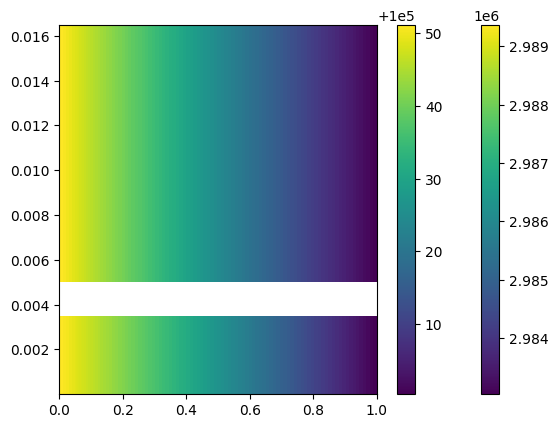

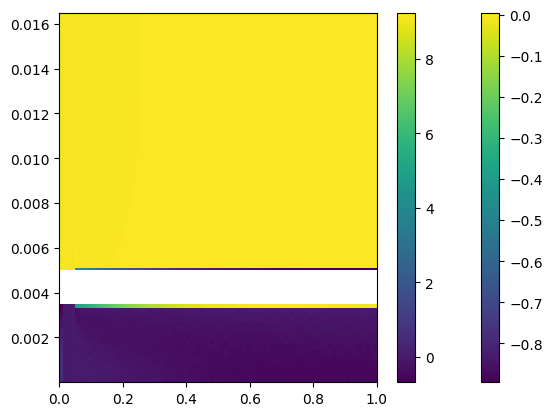

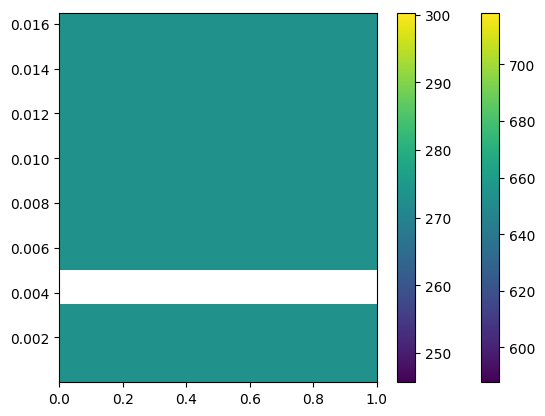

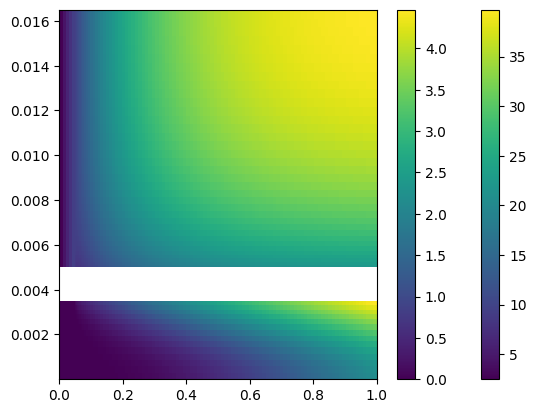

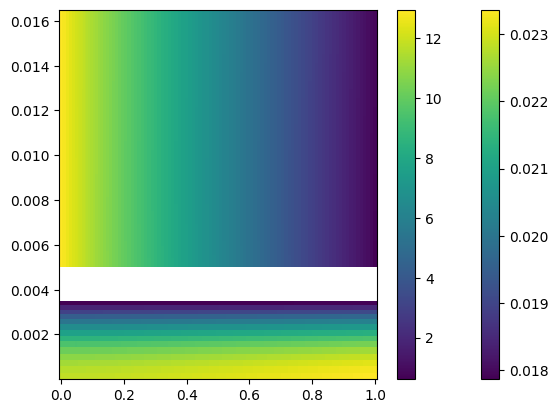

[[0.006      0.004      0.        ]
 [0.00380691 0.0033453  0.0005063 ]]
[[0.006      0.004      0.        ]
 [0.00625996 0.00401032 0.00078246]]
total balance per component: [ 0.00193313  0.00064438 -0.00128875]
elemental H balance: -1.4041697969299771e-09
elemental N balance: -2.0705655722971783e-11


In [45]:
from matplotlib import pyplot as plt
import numpy as np
import importlib
#import membrane_reactor_coupled
#importlib.reload(membrane_reactor_coupled)
import membrane_reactor
importlib.reload(membrane_reactor)
from membrane_reactor import MembraneReactor

F = 1e-2 # moles per second, 2e-4 mol/s
membrane_reactor = MembraneReactor('input.json', F_ret_in = F, F_perm_in = F, is_counter_current=False, num_pressure_iterations=5, num_newton_iterations=10, dt = 1e1, num_timesteps = 20, rtol_dc = 1e-6, rtol = 1e-4, atol_p = 1.0)
membrane_reactor.info()
    
p = membrane_reactor.p
p_vect = p.ravel()
p_perm = p[:, :membrane_reactor.num_r_perm]
p_ret = p[:, membrane_reactor.num_r_perm:]

i, j, k, cnt_p, cnt_c= membrane_reactor.solve()
print(f'number of time steps: {i}, number of iterations: {j}, number of pressure iterations: {k}  ')
print(f'number of solves for pressure: {cnt_p}, number of solves for concentration: {cnt_c}')
#g, jac =membrane_reactor.solve2()

#plt.plot(membrane_reactor.z_c[:], g[:, 0, 0])
#plt.show()

p_min = np.min(p)
p_max = np.max(p)
plt.pcolormesh(membrane_reactor.z_c, membrane_reactor.r_c_ret, p_ret[:, :].T)
plt.colorbar()
plt.pcolormesh(membrane_reactor.z_c, membrane_reactor.r_c_perm, p_perm[:, :].T)
plt.colorbar()
plt.show()

plt.pcolormesh(membrane_reactor.z_c, membrane_reactor.r_c_ret, membrane_reactor.div_u[:, membrane_reactor.num_r_perm:].T)
plt.colorbar()
plt.pcolormesh(membrane_reactor.z_c, membrane_reactor.r_c_perm, membrane_reactor.div_u[:, :membrane_reactor.num_r_perm].T)
plt.colorbar()
plt.show()

T_perm = membrane_reactor.T[:, :membrane_reactor.num_r_perm]
T_ret = membrane_reactor.T[:, membrane_reactor.num_r_perm:]
plt.pcolormesh(membrane_reactor.z_c, membrane_reactor.r_c_ret, T_ret[:, :].T)
plt.colorbar()
plt.pcolormesh(membrane_reactor.z_c, membrane_reactor.r_c_perm, T_perm[:, :].T)
plt.colorbar()
plt.show()

c_perm = membrane_reactor.c[:, :membrane_reactor.num_r_perm,:]
c_ret = membrane_reactor.c[:, membrane_reactor.num_r_perm:,:]
plt.pcolormesh(membrane_reactor.z_c, membrane_reactor.r_c_ret, c_ret[:, :, 2].T)
plt.colorbar()
plt.pcolormesh(membrane_reactor.z_c, membrane_reactor.r_c_perm, c_perm[:, :, 2].T)
plt.colorbar()
plt.show()

plt.pcolormesh(membrane_reactor.z_f, membrane_reactor.r_c_ret, membrane_reactor.u_ret_ax.T)
plt.colorbar()
plt.pcolormesh(membrane_reactor.z_f, membrane_reactor.r_c_perm, membrane_reactor.u_perm_ax.T)
plt.colorbar()
plt.show()
#plt.plot(membrane_reactor.z_f, membrane_reactor.u_ret_ax[:, 10], '.')
#plt.show()

flows_ret_ax, flows_ret_rad, flows_perm_ax, flows_perm_rad = membrane_reactor.compute_flows()

print(flows_ret_ax[[0,-1],:])
#print(flows_ret_rad[[0,-1],:])
print(flows_perm_ax[[0,-1],:])
#print(flows_perm_rad[[0,-1],:])
flows_tot = flows_ret_ax[0,:] + flows_perm_ax[0,:] -  flows_ret_ax[-1,:] - flows_perm_ax[-1,:]
print(f'total balance per component: {flows_tot}')
print(f'elemental H balance: {2*flows_tot[0] + 3*flows_tot[2]}')
print(f'elemental N balance: {2*flows_tot[1] + flows_tot[2]}')


537.4538545326533


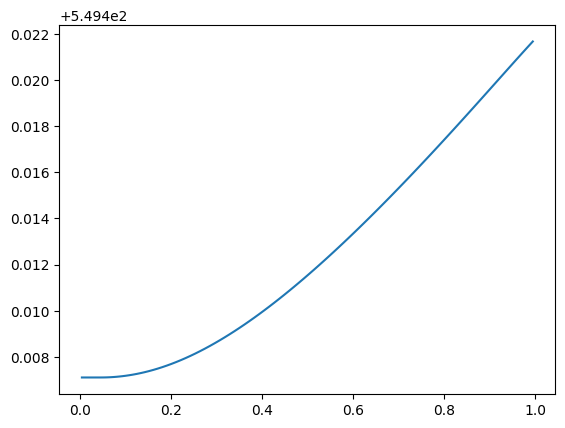

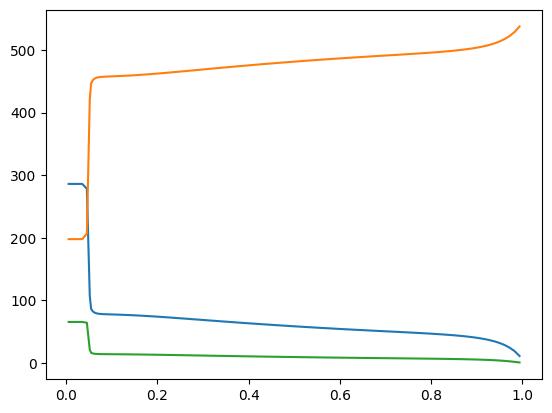

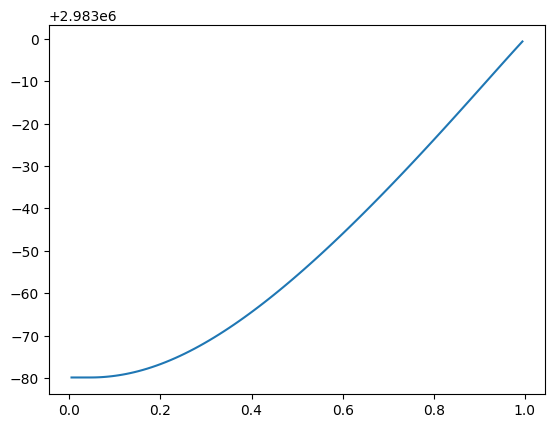

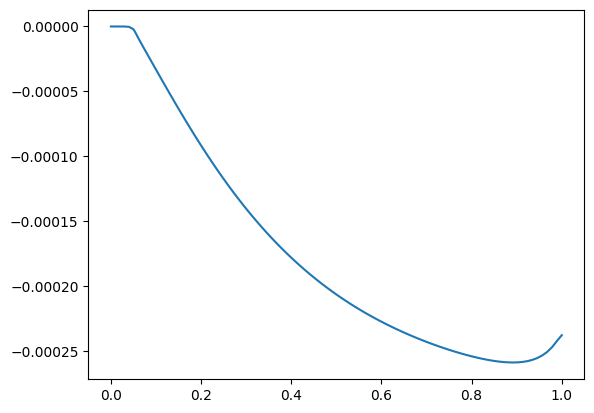

In [37]:
print(np.max(membrane_reactor.c))

#plt.pcolormesh(membrane_reactor.z_c, membrane_reactor.r_c_ret, c_ret[:, :, 2].T)
#plt.colorbar()
#plt.show()

plt.plot(membrane_reactor.z_c, np.sum(c_ret[:, -1, :], axis=-1))
plt.show()

plt.plot(membrane_reactor.z_c, c_ret[:, -1, 0])
plt.plot(membrane_reactor.z_c, c_ret[:, -1, 1])
plt.plot(membrane_reactor.z_c, c_ret[:, -1, 2])
plt.show()

plt.plot(membrane_reactor.z_c, membrane_reactor.p[:, -1])
plt.show()

#plt.plot(membrane_reactor.z_f, flows_ret_ax[:, 0])
plt.plot(membrane_reactor.z_f, membrane_reactor.u_ret_ax[:, -1])
plt.show()


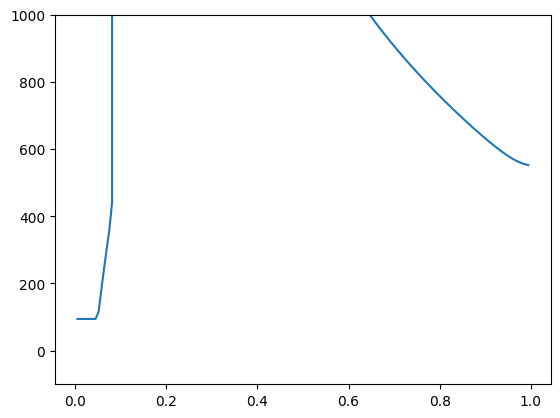

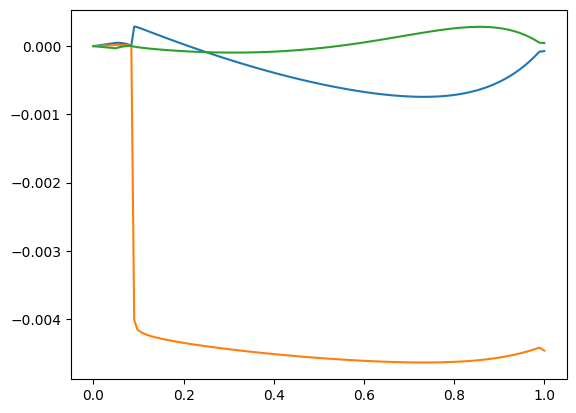

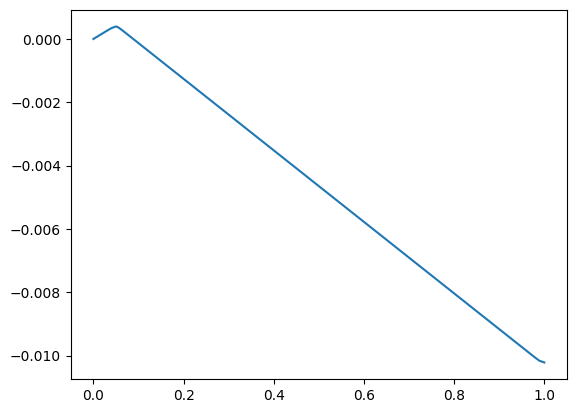

In [123]:
plt.plot(membrane_reactor.z_c, np.sum(membrane_reactor.c[:, -1, :], axis = -1))
plt.ylim([-100,1000])
plt.show()

flows_ret_ax, flows_ret_rad, flows_perm_ax, flows_perm_rad = membrane_reactor.compute_flows()
plt.plot(membrane_reactor.z_f, flows_ret_ax[:, :])
#plt.plot(membrane_reactor.z_f, np.sum(flows_ret_ax[:, :], axis=-1))
plt.show()

plt.plot(membrane_reactor.z_f, membrane_reactor.u_ret_ax[:,-1])
plt.show()

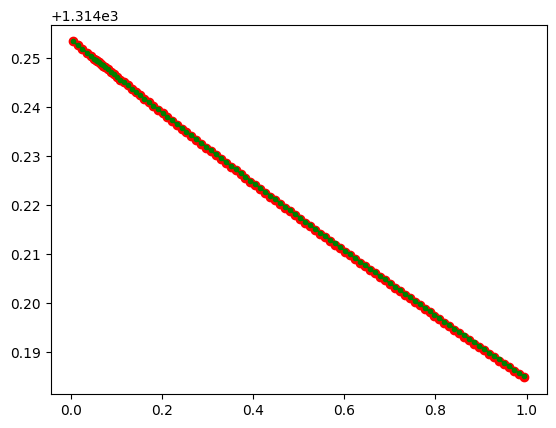

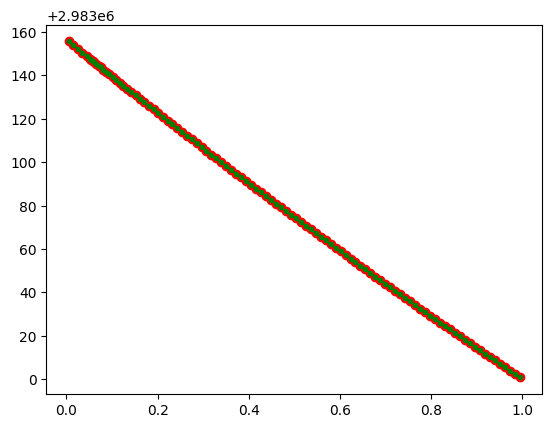

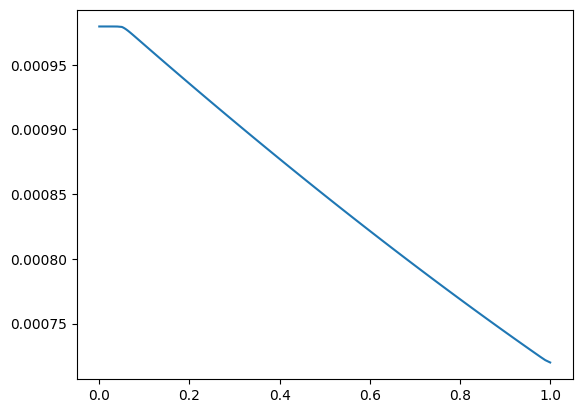

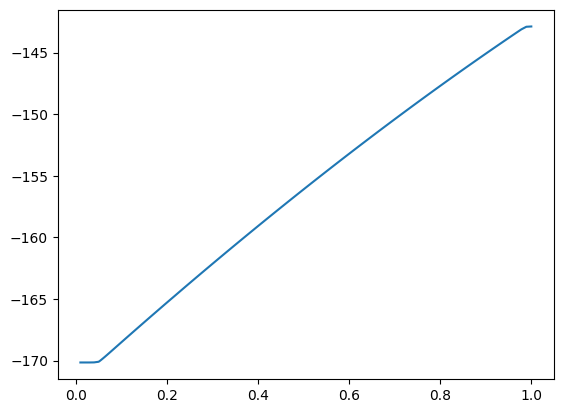

In [80]:
from scipy import constants
c_tot = np.sum(membrane_reactor.c,axis=-1)
y = membrane_reactor.c / c_tot[..., np.newaxis]
c_tot_p = membrane_reactor.correlation.molar_density(y, membrane_reactor.T, membrane_reactor.p)

plt.plot(membrane_reactor.z_c, c_tot[:,-1], 'o-r')
plt.plot(membrane_reactor.z_c, c_tot_p[:, -1], '.-g')
plt.show()

#plt.plot(membrane_reactor.z_c, c_tot[:,0], 'o-r')
#plt.plot(membrane_reactor.z_c, c_tot_p[:,0], '.-g')
#plt.show()

p_ig = c_tot_p * constants.R * membrane_reactor.T
plt.plot(membrane_reactor.z_c, p_ig[:,-1], 'o-r')
plt.plot(membrane_reactor.z_c, membrane_reactor.p[:, -1], '.-g')
plt.show()

#plt.plot(membrane_reactor.z_c, p_ig[:,0], 'o-r')
#plt.plot(membrane_reactor.z_c, membrane_reactor.p[:,-1], '.-g')
#plt.show()

plt.plot(membrane_reactor.z_f, membrane_reactor.u_ret_ax[:,-1], '-')
plt.show()

grad_p = membrane_reactor.grad_p_ret_ax @ membrane_reactor.p.reshape((-1,1)) + membrane_reactor.grad_bc_p_ret_ax
grad_p = grad_p.reshape((membrane_reactor.num_z+1,-1))
plt.plot(membrane_reactor.z_f[1:], grad_p[1:,-1], '-')
plt.show()

In [81]:
from scipy.sparse.linalg import spsolve, lsqr

max_trial = 1
A = jac
# Estimate operator norm using 1-norm
max_norm_A = 0.0
for i in range(max_trial):
    # Generate a random vector
    x = np.random.rand(A.shape[1])
    x /= np.linalg.norm(x)  # Normalize x to unit norm
    Ax = A @ x
    norm_Ax = np.linalg.norm(Ax, ord=1)
    max_norm_A = max(max_norm_A, norm_Ax)

# Estimate inverse norm by solving A x = b
# (Assumes A is invertible and gmres converges)
max_norm_A_inv = 0.0
for i in range(max_trial):
    # Generate a random vector
    b = np.random.rand(A.shape[0])
    b /= np.linalg.norm(b)  # Normalize b to unit norm
    x = spsolve(A, b)
    #result = lsqr(A,b)  # Use lsqr to solve Ax = b
    #x = result[0]
    norm_A_inv = np.linalg.norm(x, ord=1)
    max_norm_A_inv = max(max_norm_A_inv, norm_A_inv)

cond_est = max_norm_A * max_norm_A_inv
print(f'Condition number estimate: {cond_est:.4e}')

NameError: name 'jac' is not defined

In [ ]:
A = jac.toarray()
print(A[np.ravel_multi_index([0,0,0],membrane_reactor.cp.shape),:].reshape(membrane_reactor.cp.shape))

AttributeError: 'MembraneReactor' object has no attribute 'cp'

In [ ]:
A[:,np.ravel_multi_index([1,1,0],membrane_reactor.cp.shape)]

array([ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
       -9.81647685e-04,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
       -8.01345049e+01,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        8.01354865e+01,  0.00000000e+00,  0.00000000e+00,  1.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00])

In [ ]:
i=0
j=0
A = jac.toarray()
for i in range(membrane_reactor.cp.shape[0]-1):
    for j in range(membrane_reactor.cp.shape[1]):
        print(i, j, A[np.ravel_multi_index([i,j,0],membrane_reactor.cp.shape),np.ravel_multi_index([i+1,j,0],membrane_reactor.cp.shape)], membrane_reactor._jac.toarray()[np.ravel_multi_index([i+1,j,0],membrane_reactor.cp.shape),np.ravel_multi_index([i,j,0],membrane_reactor.cp.shape)])
        
for i in range(membrane_reactor.cp.shape[0]):
    for j in range(membrane_reactor.cp.shape[1]-1):
        print(A[np.ravel_multi_index([i,j,0],membrane_reactor.cp.shape),np.ravel_multi_index([i,j+1,0],membrane_reactor.cp.shape)], membrane_reactor._jac.toarray()[np.ravel_multi_index([i,j+1,0],membrane_reactor.cp.shape),np.ravel_multi_index([i,j,0],membrane_reactor.cp.shape)])

0 0 -0.0010638310372359321 -916.6514846049316
0 1 -0.0010638310372397828 -427.77125991319866
0 2 -4.333170674152497e-05 -1.0617319038682242
0 3 -4.333170674154796e-05 -1.061731903868221
-86.4288401330732 -108.15735575807318
0.0 0.0
-0.3261087946733484 -0.3261087946733482
-87.25785982412799 -87.25785982412799
0.0 0.0
-0.3291911183212236 -0.329191118242137


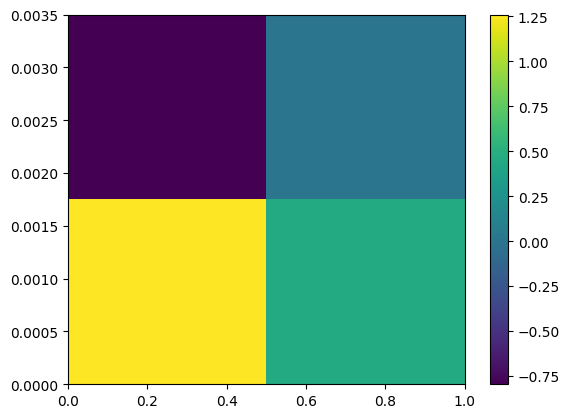

(np.int64(0), np.int64(0), np.int64(0))


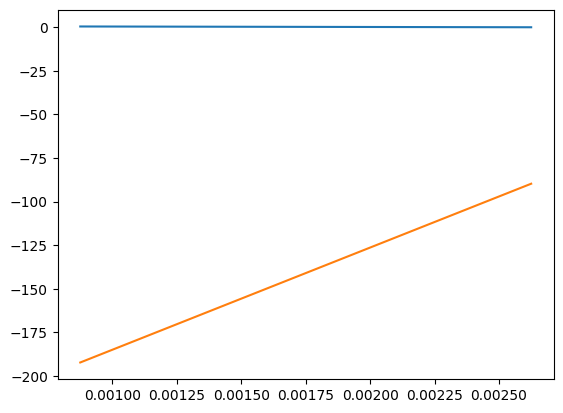

In [ ]:
dg_rel = dg/(np.abs(g)+1e-12)
g_perm = g[:, :membrane_reactor.num_r_perm,:]
g_ret = g[:, membrane_reactor.num_r_perm:,:]
dg_perm = dg[:, :membrane_reactor.num_r_perm,:]
dg_ret = dg[:, membrane_reactor.num_r_perm:,:]
dg_rel_perm = dg[:, :membrane_reactor.num_r_perm,:]
dg_rel_ret = dg[:, membrane_reactor.num_r_perm:,:]
#plt.pcolormesh(membrane_reactor.z_c, membrane_reactor.r_c_ret, dg_rel_ret[:, :,0].T)
#plt.colorbar()
plt.pcolormesh(membrane_reactor.z_c, membrane_reactor.r_c_perm, dg_rel_perm[:, :,0].T)
plt.colorbar()
plt.show()

print(np.unravel_index(np.argmax(dg_perm),dg_perm.shape))
plt.plot(membrane_reactor.r_c_perm, dg_perm[1, :, 0])
plt.plot(membrane_reactor.r_c_perm, g_perm[1, :, 0])
plt.show()



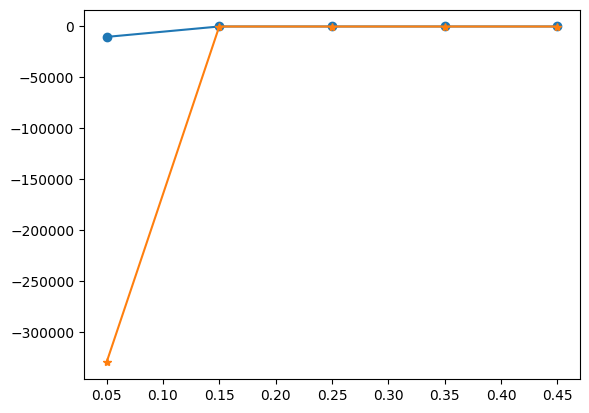

10249.43397689303


In [ ]:

#plt.plot(membrane_reactor.z_c[0:5], np.sum(g[0:5,0,:-1],axis=-1),'o-')
plt.plot(membrane_reactor.z_c[0:5], g[0:5,0,0],'o-')
plt.plot(membrane_reactor.z_c[0:5], g_post[0:5,-1,0],'*-')
#plt.plot(g[0,:,0])
plt.show()
print(np.linalg.norm(g.ravel(),ord=np.inf))

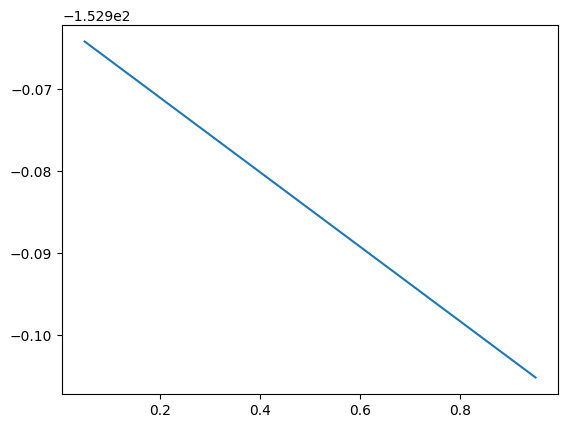

In [ ]:
plt.plot(membrane_reactor.z_c, membrane_reactor.cp[:,0,0])
plt.show()

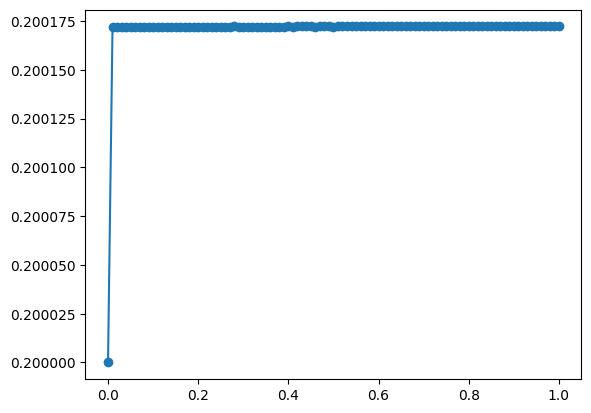

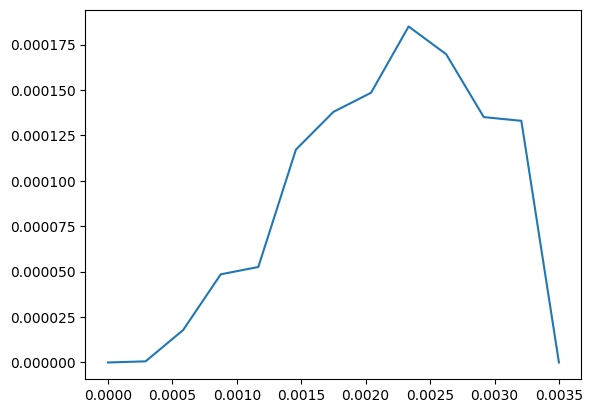

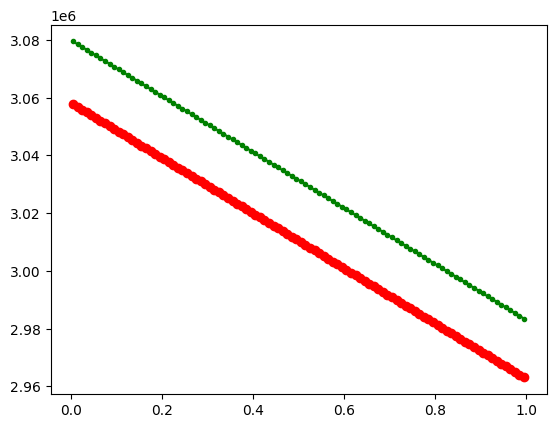

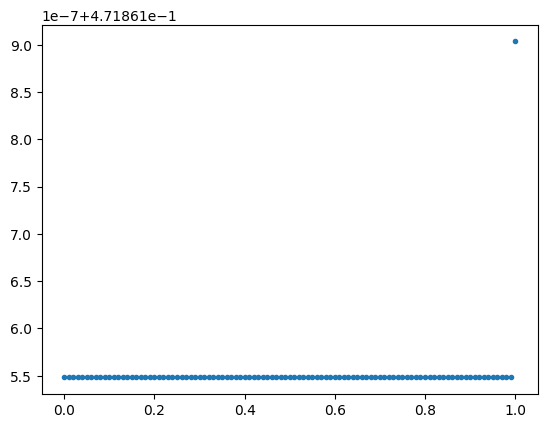

In [ ]:
from scipy import constants
flows_ret_ax, flows_ret_rad, flows_perm_ax, flows_perm_rad = membrane_reactor.compute_flows(cp = membrane_reactor.cp_prev)
#plt.plot(membrane_reactor.z_c, membrane_reactor.cp[:,-1, 0])
#plt.show()

plt.plot(membrane_reactor.z_f, flows_perm_ax[:,0],'o-')
#plt.plot(membrane_reactor.z_f, flows_ret_ax[:,2])
#plt.plot(membrane_reactor.z_f, flows_perm_ax[:,1])
#plt.plot(membrane_reactor.z_f, flows_perm_ax[:,2])
plt.show()

#plt.plot(membrane_reactor.z_c, membrane_reactor.cp[:,0,0],'o-')
plt.plot(membrane_reactor.r_f_perm, flows_perm_rad[:,0])
#plt.plot(membrane_reactor.z_f, flows_perm_ax[:,1])
#plt.plot(membrane_reactor.z_f, flows_perm_ax[:,2])
plt.show()

p_ig = np.sum(membrane_reactor.cp[:,:,:3],axis=-1)*membrane_reactor.T*constants.R
plt.plot(membrane_reactor.z_c, p_ig[:,-1], 'o-r')

plt.plot(membrane_reactor.z_c, membrane_reactor.cp[:, -1, -1], '.-g')
plt.show()

plt.plot(membrane_reactor.z_f, membrane_reactor.u_ret_ax[:, -1], '.')
plt.show()

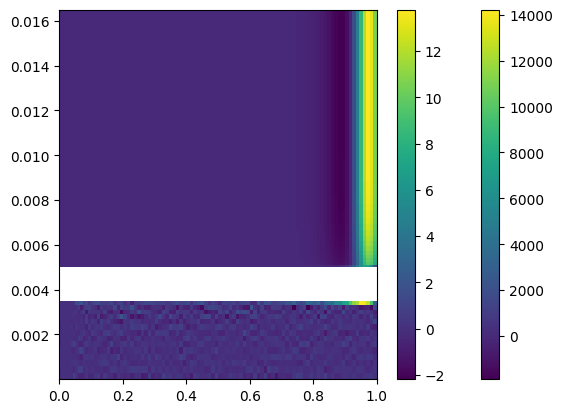

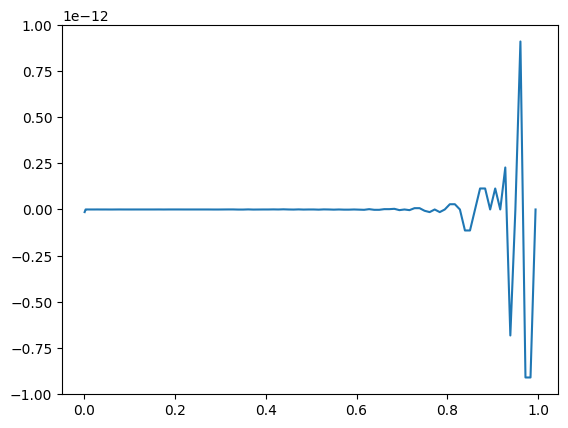

In [ ]:
g_perm = g.reshape(membrane_reactor.c.shape)[:, :membrane_reactor.num_r_perm,:]
g_ret = g.reshape(membrane_reactor.c.shape)[:, membrane_reactor.num_r_perm:,:]
g_p_perm = g_p.reshape(membrane_reactor.p.shape)[:, :membrane_reactor.num_r_perm]
g_p_ret = g_p.reshape(membrane_reactor.p.shape)[:, membrane_reactor.num_r_perm:]

plt.pcolormesh(membrane_reactor.z_c, membrane_reactor.r_c_ret, g_p_ret[:, :].T)
plt.colorbar()
plt.pcolormesh(membrane_reactor.z_c, membrane_reactor.r_c_perm, g_p_perm[:, :].T)
plt.colorbar()
plt.show()

plt.plot(membrane_reactor.z_c, np.sum(g_ret[:, -1,:], axis=-1))
#plt.plot(membrane_reactor.z_c[1:50], g_p_ret[1:50, -1])
plt.show()
